In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_json('../original_datasets/gps_routes.json')

print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   route_id              4000 non-null   str    
 1   vehicle_id            4000 non-null   str    
 2   vehicle_type          4000 non-null   str    
 3   route_date            4000 non-null   str    
 4   order_ids             4000 non-null   object 
 5   planned_distance_km   4000 non-null   float64
 6   actual_distance_km    3745 non-null   float64
 7   planned_duration_min  4000 non-null   float64
 8   actual_duration_min   4000 non-null   float64
 9   stops_planned         4000 non-null   int64  
 10  stops_completed       4000 non-null   int64  
 11  waypoints             4000 non-null   object 
 12  fuel_or_energy_used   4000 non-null   object 
 13  driver_id             3030 non-null   str    
dtypes: float64(4), int64(2), object(3), str(5)
memory usage: 437.6+ KB
None
       plan

In [3]:
# Check duplicates only on primary columns
print(df[['route_id', 'vehicle_id', 'vehicle_type', 'driver_id']].duplicated().sum())

0


In [5]:
print(df.isna().sum())

route_id                  0
vehicle_id                0
vehicle_type              0
route_date                0
order_ids                 0
planned_distance_km       0
actual_distance_km      255
planned_duration_min      0
actual_duration_min       0
stops_planned             0
stops_completed           0
waypoints                 0
fuel_or_energy_used       0
driver_id               970
dtype: int64


In [6]:
import pandas as pd

# 1. Fill missing values in 'actual_distance_km' with the median of the column
median_distance = df['actual_distance_km'].median()
df['actual_distance_km'] = df['actual_distance_km'].fillna(median_distance)

# 2. Fill missing values in 'driver_id' with a placeholder text
df['driver_id'] = df['driver_id'].fillna('Not Assigned')

# 3. Verify that all nulls have been filled (should all show 0)
print("Remaining null values after filling:")
print(df[['actual_distance_km', 'driver_id']].isnull().sum())

Remaining null values after filling:
actual_distance_km    0
driver_id             0
dtype: int64


In [7]:
print(df.isna().sum())

route_id                0
vehicle_id              0
vehicle_type            0
route_date              0
order_ids               0
planned_distance_km     0
actual_distance_km      0
planned_duration_min    0
actual_duration_min     0
stops_planned           0
stops_completed         0
waypoints               0
fuel_or_energy_used     0
driver_id               0
dtype: int64


In [12]:
# Save the dataframe to a CSV file (index=False prevents saving the row numbers)
df.to_csv('cleaned_gps_routes.csv', index=False)

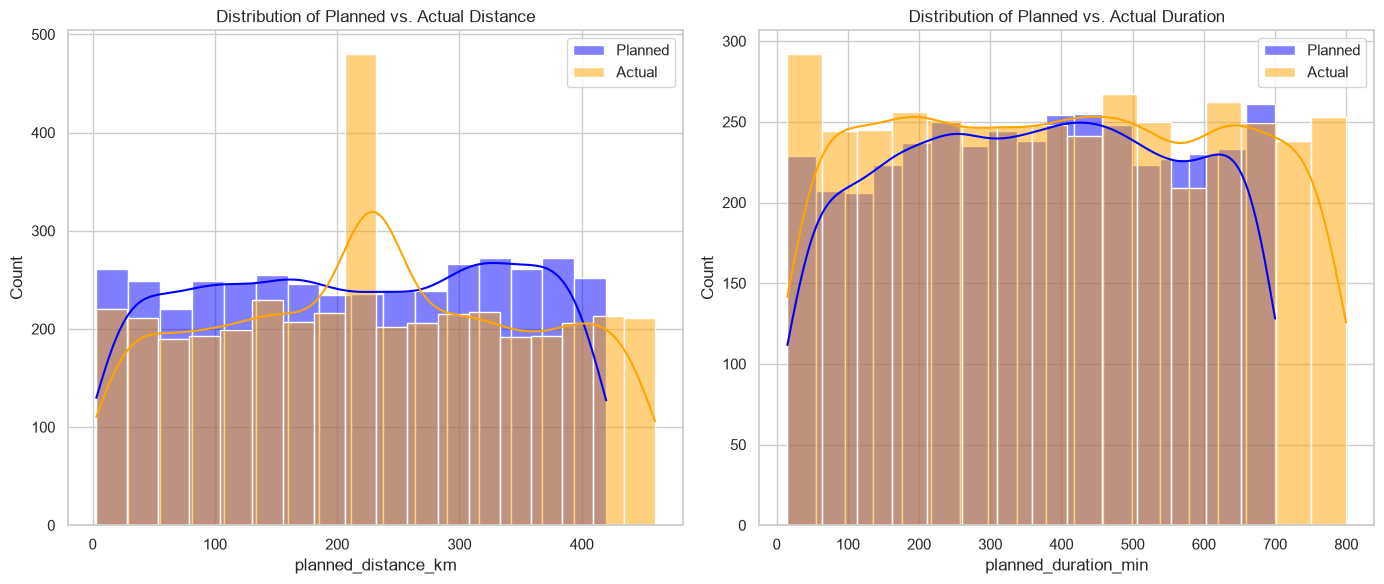

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution of Distances
sns.histplot(data=df, x='planned_distance_km', color='blue', label='Planned', kde=True, ax=axes[0], alpha=0.5)
sns.histplot(data=df, x='actual_distance_km', color='orange', label='Actual', kde=True, ax=axes[0], alpha=0.5)
axes[0].set_title('Distribution of Planned vs. Actual Distance')
axes[0].legend()

# Distribution of Durations
sns.histplot(data=df, x='planned_duration_min', color='blue', label='Planned', kde=True, ax=axes[1], alpha=0.5)
sns.histplot(data=df, x='actual_duration_min', color='orange', label='Actual', kde=True, ax=axes[1], alpha=0.5)
axes[1].set_title('Distribution of Planned vs. Actual Duration')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Create a column for distance discrepancy (Actual - Planned)
df['distance_diff_km'] = df['actual_distance_km'] - df['planned_distance_km']

# Define an outlier threshold (e.g., routes where the actual distance differed by more than 100 km)
outliers = df[abs(df['distance_diff_km']) > 100]

print(f"Found {len(outliers)} major route distance outliers:")
print(outliers[['route_id', 'planned_distance_km', 'actual_distance_km', 'distance_diff_km']])

Found 2384 major route distance outliers:
       route_id  planned_distance_km  actual_distance_km  distance_diff_km
0     RTE-00001                13.68              242.92            229.24
1     RTE-00002               352.54              129.90           -222.64
4     RTE-00005               361.05               28.40           -332.65
5     RTE-00006               152.53              418.89            266.36
7     RTE-00008               414.24              190.54           -223.70
...         ...                  ...                 ...               ...
3993  RTE-03994               189.40              299.02            109.62
3994  RTE-03995               121.72              399.30            277.58
3996  RTE-03997                24.23              332.85            308.62
3997  RTE-03998               170.66              327.70            157.04
3998  RTE-03999               171.39              453.64            282.25

[2384 rows x 4 columns]


In [13]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv('cleaned_gps_routes.csv')

# Calculate IQR for actual distance
Q1 = df['actual_distance_km'].quantile(0.25)
Q3 = df['actual_distance_km'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds to filter out extreme system errors/typos
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to keep realistic operational variations
df_filtered = df[(df['actual_distance_km'] >= lower_bound) & (df['actual_distance_km'] <= upper_bound)]

print(f"Original rows: {len(df)}")
print(f"Rows after handling extreme outliers: {len(df_filtered)}")

Original rows: 4000
Rows after handling extreme outliers: 4000


In [14]:
print(df.describe())

       planned_distance_km  actual_distance_km  planned_duration_min  \
count          4000.000000         4000.000000           4000.000000   
mean            214.131703          231.147863            363.397400   
std             121.406948          127.666473            196.007981   
min               3.010000            3.010000             15.100000   
25%             108.985000          128.560000            197.050000   
50%             215.065000          229.730000            365.350000   
75%             321.052500          335.787500            528.150000   
max             419.980000          459.930000            700.000000   

       actual_duration_min  stops_planned  stops_completed  distance_diff_km  
count          4000.000000    4000.000000      4000.000000       4000.000000  
mean            402.383500       5.006500         4.824500         17.016160  
std             228.597721       2.600028         2.648292        177.155773  
min              15.000000       1.

In [15]:
print(f"Initial row count: {len(df)}")

# 1. Identify and inspect failed/abandoned trips (0 stops completed but distance logged)
failed_trips = df[df['stops_completed'] == 0]
print(f"Number of failed/abandoned trips (0 stops completed): {len(failed_trips)}")

# 2. Flag extreme distance anomalies (e.g., actual distance differs by more than 300 km from planned)
extreme_deviations = df[abs(df['distance_diff_km']) > 300]
print(f"Number of extreme distance deviations (>300 km diff): {len(extreme_deviations)}")

# 3. Create a clean dataset for ML training
# We filter out trips with 0 completed stops and extreme routing anomalies
df_cleaned = df[
    (df['stops_completed'] > 0) & 
    (abs(df['distance_diff_km']) <= 300)
].copy()

print(f"Final cleaned row count for model training: {len(df_cleaned)}")

Initial row count: 4000
Number of failed/abandoned trips (0 stops completed): 82
Number of extreme distance deviations (>300 km diff): 377
Final cleaned row count for model training: 3548


In [16]:
df.to_csv('cleaned_gps_routes.csv', index=False)